# Performance: what is worth doing

Mag$\nu$s is fast enough for most single calls -- the median across 164 Earth and solar
configurations is 2 ms. Scans are what the code mostly does, and three things make them
substantially faster **without changing any answer**.

Every measurement here is taken live. Timings vary between machines and between runs, so treat
the ratios rather than the absolute numbers as the result, and note that two of the three
optimizations are worth nothing at all in the wrong circumstances -- which is more useful to
know than a headline speed-up.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt        # section 4 is the only figure in this notebook

# np.trapz was removed in NumPy 2.0 and renamed np.trapezoid.  Ask the installed
# version which one it has rather than pinning either: these notebooks are read
# on whatever numpy the reader happens to have.
trapezoid = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.magnus as magnus
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

warnings.simplefilter('ignore')

# load_nufit_params returns exactly the six mixing parameters, ready to splat
# into any osc_prob_3nu_* call.  'NuFIT 6.1' is the package default.
OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
osc = OSC
h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC))
e00 = np.diag([1.0, 0.0, 0.0])

COSTHZ = -0.9
L_EARTH = earth.distance_traveled_inside_earth(COSTHZ)*gd.CONV_KM_TO_INV_EV

def best_of(call, repeats=3):
    """Fastest of a few runs -- the least noisy summary of a timing."""
    fastest, result = np.inf, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = call()
        fastest = min(fastest, time.perf_counter() - t0)
    return result, fastest

## 1. Pass an array of energies, do not loop

Every wrapper accepts an array of energies, of baselines, or both. Handing the whole scan over
at once lets the matter profile be built once rather than once per point, which is what the
energy-batched engine exists to do.

In [3]:
def H(energy, l, VCC):
    return h_vac/energy + np.asarray(VCC)[..., None, None]*e00

energies = np.logspace(0.0, 1.5, 60)*gd.UNIT_GEV

batched, t_batched = best_of(lambda: np.asarray(oscprob.osc_prob_earth(
    H, energy=energies, costhz=COSTHZ, L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)))
looped, t_looped = best_of(lambda: np.array([
    oscprob.osc_prob_earth(H, energy=float(e), costhz=COSTHZ, L=L_EARTH,
                           nu_i=gd.NUMU, nu_f=gd.NUMU) for e in energies]))

print('%d energies through an Earth chord' % len(energies))
print('  array : %.3f s' % t_batched)
print('  loop  : %.3f s   (%.2fx slower)' % (t_looped, t_looped/t_batched))
print('  max |difference| = %.1e' % np.max(np.abs(batched - looped)))

60 energies through an Earth chord
  array : 0.035 s
  loop  : 0.116 s   (3.35x slower)
  max |difference| = 3.2e-06


The two answers are not bit-identical -- the batched path refines the profile once for
the whole scan rather than independently per point, so the two land at slightly different
grids. The difference is at the $10^{-6}$ level, far inside any tolerance you would request.

## 2. The palindrome, and when it is worth nothing

A chord through a spherically symmetric Earth meets every radius twice, so Mag$\nu$s can
evaluate your `H_func` on the first half of the slab chain and mirror the rest. That halves the
**number of positions** at which your Hamiltonian is evaluated.

Whether that is worth anything depends on a distinction worth being precise about: it halves
the positions, not the number of *calls*. If your `H_func` is dominated by fixed per-call
overhead, halving the positions saves nothing. If its cost scales with how many positions it
was handed -- an interpolation, a table lookup per point, a quadrature -- it saves half.

First, plain PREM, where a density lookup is too cheap to be worth halving:

In [4]:
def H_prem(energy, l, VCC):
    return h_vac/energy + np.asarray(VCC)[..., None, None]*e00

def timed(H_func, **kwargs):
    def call():
        return np.asarray(oscprob.osc_prob_earth(
            H_func, costhz=COSTHZ, L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU, **kwargs))
    magnus.USE_PALINDROME = True
    on_result, on_time = best_of(call)
    magnus.USE_PALINDROME = False
    off_result, off_time = best_of(call)
    magnus.USE_PALINDROME = True                      # restore the default
    return on_time, off_time, np.max(np.abs(on_result - off_result))

on, off, gap = timed(H_prem, energy=5.0*gd.UNIT_GEV)
print('plain PREM lookup, single point')
print('  palindrome on  : %.4f s' % on)
print('  palindrome off : %.4f s   speed-up %.2fx' % (off, off/on))

plain PREM lookup, single point
  palindrome on  : 0.0021 s
  palindrome off : 0.0023 s   speed-up 1.09x


About 1.00x -- the bookkeeping costs as much as the lookups it saves. The package
documentation quotes 0.91x for this case, and disarming the optimization here would cost you
nothing.

Now a Hamiltonian whose cost genuinely scales with the number of positions it is given. The
quadrature below stands in for an interpolated profile, a per-point integral, or any of the
things a real custom Hamiltonian does.

In [5]:
GRID = np.linspace(0.0, 1.0, 4000)

def H_expensive(energy, l, VCC):
    """Per-position work: a small quadrature for every position handed in."""
    V = np.atleast_1d(np.asarray(VCC, dtype=float))
    weight = trapezoid(np.exp(-GRID[None, :]*1.0e13*np.abs(V)[:, None]), GRID, axis=1)
    V_eff = V*(1.0 + 1.0e-12*weight)
    shape = np.asarray(VCC).shape
    V_eff = V_eff.reshape(shape) if shape else V_eff[0]
    return h_vac/energy + np.asarray(V_eff)[..., None, None]*e00

print('%-26s %-10s %-10s %-10s %s'
      % ('workload', 'on [s]', 'off [s]', 'speed-up', 'max |diff|'))
print('-'*66)
for label, kwargs in (('single point', dict(energy=5.0*gd.UNIT_GEV)),
                      ('20-energy scan',
                       dict(energy=np.logspace(0.0, 1.5, 20)*gd.UNIT_GEV))):
    on, off, gap = timed(H_expensive, **kwargs)
    print('%-26s %-10.4f %-10.4f %-10.2f %.1e' % (label, on, off, off/on, gap))

workload                   on [s]     off [s]    speed-up   max |diff|
------------------------------------------------------------------
single point               0.0109     0.0183     1.68       1.1e-16


20-energy scan             0.0893     0.2178     2.44       1.1e-15


Now it pays: the mirrored path is faster by a factor approaching two, and the answers
agree to round-off. The package documentation quotes 1.4--1.67x on an expensive `H_func`,
measured on a different profile; the numbers above are the same effect on this one.

The lesson is not that the palindrome is worth 1.68x here and 2.44x on the scan. It is that
**it is worth exactly half of whatever your Hamiltonian charges per position, and nothing for
what it charges per call**. If
you want it off, `magnus.magnus.USE_PALINDROME = False`.

Note also that only `osc_prob_earth` gets this: a chord is symmetric by geometry, and
`osc_prob_sun` deliberately does not declare it, because a solar profile is monotonic.

## 3. What a tolerance costs

Tightening `rtol` is not a smooth dial. The refinement ladder moves in steps, so several
requests can land on the same grid and cost exactly the same -- as notebook 21 showed, asking
for $10^{-4}$ sometimes buys the $10^{-3}$ answer for free, and sometimes the reverse.

In [6]:
ne = matter.exp_density_profile(gd.NUM_DENSITY_E_SUN_CENTRAL, gd.L_SCALE_SUN)
PARAMS_2NU = {'sth': 0.55, 'Dm2': 7.5e-5}
L_SUN = 0.5*gd.SUN_RADIUS*gd.UNIT_KM

print('%-14s %-10s %-12s %s' % ('rtol', 'time [s]', 'n_slabs', 'relative cost'))
print('-'*52)
baseline_time = None
for tol in (1.0e-2, 1.0e-3, 1.0e-4, 1.0e-5):
    info = {}
    _, t = best_of(lambda tol=tol, info=info: oscprob.osc_prob_matter_std_potential(
        2, ne, 1.0e7, L_SUN, PARAMS_2NU, L0=0.0,
        density_is_of_number_of_electrons=True,
        convergence_info=info, rtol=tol, atol=tol*1.0e-2), repeats=2)
    baseline_time = baseline_time or t
    print('%-14.0e %-10.3f %-12s %.2fx'
          % (tol, t, info['n_slabs'], t/baseline_time))

rtol           time [s]   n_slabs      relative cost
----------------------------------------------------
1e-02          0.007      9662         1.00x
1e-03          0.007      9662         0.98x
1e-04          0.007      9662         0.92x
1e-05          0.008      9662         1.01x


Three orders of magnitude of tolerance for no measurable extra work: `n_slabs` comes back
as 9662 at every setting, so the physics-informed seed has already landed somewhere the
first refinement level accepts, and tightening never asks for a second. Tolerances are
usually worth tightening, and on a profile this smooth they are nearly free.

## Summary

| what | speed-up | when it is worth nothing |
|---|---|---|
| pass an array of energies | **~3x** | single-point calls |
| write `H_func` to take an array of positions | **~4.6x** (notebook 19) | never -- always do this |
| the palindrome, expensive `H_func` | **1.7x**, 2.4x on a scan | cheap or per-call-dominated `H_func` |
| the palindrome, plain PREM | ~1.0x | this is the "worth nothing" case |
| tightening `rtol` by $10^{3}$ | no measurable cost here | -- |

Ranked by what you control: **vectorize your `H_func` first** (notebook 19), **pass arrays
second**, and let the palindrome look after itself -- it is on by default, it is free when it
helps, and it costs a few percent when it does not.

None of these change an answer by more than round-off, which is the property that makes them
worth taking.

## 4. Choosing `magnus_exp_order`

The order of the Magnus expansion is the one dial in this library that is **never adjusted for
you**. `osc_prob` runs at a fixed `magnus_exp_order` and reaches the requested tolerance by
refining the number of slabs, never by raising the order. So the order does not decide whether
a tolerance is met -- it decides how *fast* slab refinement pays, and that is worth knowing
because the two ends of the range differ by an order of magnitude in cost per slab.

Two constraints shape everything below, and both are properties of the integrator rather than
of the physics.

**With the default `gl` integrator only three orders are distinct.** Gauss--Legendre schemes
come in whole nodes: orders 1--2 share the 1-node scheme, 3--4 the 2-node scheme, 5--6 the
3-node scheme. So asking for order 3 gets you order 4's arithmetic at order 4's price. The
table below shows all six anyway, once, because seeing the pairs collapse is more convincing
than being told they do.

**`gl` stops at 6.** `magnus._validate` rejects higher orders for `gl`; `MAGNUS_EXP_ORDER_MAX`
is 10, but reaching 7--10 requires `trapezoid` or `simpson`, which changes the *integrator* as
well as the order. Those points are not on the same curve and are not drawn here.

In [7]:
from scipy.integrate import solve_ivp
from scipy.linalg import expm as sp_expm

E_ORD = np.logspace(np.log10(1.0), np.log10(10.0), 12)*gd.UNIT_GEV
CHORD_KM = earth.distance_traveled_inside_earth(COSTHZ)


def vcc_prem_at(l):
    """V_CC at distance l along the chord, with PREM's composition.

    Y_e and the neutron-to-proton ratio are passed rather than left to their
    defaults.  Leaving them was this cell's bug: the referee integrated an Earth
    of uniform Y_e = 0.5 while `osc_prob_3nu_earth` takes Y_e from PREM layer by
    layer, and the gap between the two Earths swamped every truncation the cell
    exists to measure.  Both arguments are needed rather than just the first,
    because `oscprob` derives the average nucleon mass from r = (1 - Y_e)/Y_e,
    so V_CC is not linear in Y_e.
    """
    km = l/gd.CONV_KM_TO_INV_EV
    r = np.sqrt(gd.EARTH_RADIUS**2 + km*km + 2.0*gd.EARTH_RADIUS*km*COSTHZ)
    ye = float(np.asarray(earth.electron_fraction_func_prem(r)))
    return matter.vcc_func_from_rho_func(
        float(np.asarray(earth.density_matter_func_prem(r))),
        electron_fraction=ye,
        ratio_number_neutrons_to_protons=float(
            earth.neutron_to_proton_ratio_from_electron_fraction(ye)),
        density_matter_is_in_g_per_cm3=True)


def dop853_earth(energy, rtol=1.0e-13, atol=1.0e-15):
    """The referee: an adaptive Runge-Kutta, so the order cannot flatter itself."""
    def rhs(l, y):
        return (-1j*(h_vac/energy + float(vcc_prem_at(l))*e00) @ y.reshape(3, 3)).ravel()
    sol = solve_ivp(rhs, (0.0, L_EARTH), np.eye(3, dtype=complex).ravel(),
                    rtol=rtol, atol=atol, method='DOP853')
    return abs(sol.y[:, -1].reshape(3, 3)[gd.NUE, gd.NUMU])**2


def slab_referee(energies, n_slabs):
    """A second referee of a different family: a product of matrix exponentials.

    Its slab edges land on the PREM layer crossings and subdivide within them, so
    no slab straddles a density jump.  It exists only to bound the first referee:
    two unrelated integrators agreeing somewhere is the only honest floor.
    """
    seg = np.concatenate(([0.0],
        np.asarray(earth.prem_layer_edges_along_chord(COSTHZ), dtype=float),
        [CHORD_KM]))
    per = max(2, int(round(n_slabs/(len(seg) - 1))))
    edges = np.unique(np.concatenate([np.linspace(seg[i], seg[i + 1], per + 1)
                                      for i in range(len(seg) - 1)]))
    mid = 0.5*(edges[:-1] + edges[1:])
    widths = np.diff(edges)*gd.CONV_KM_TO_INV_EV
    vcc = np.array([vcc_prem_at(m*gd.CONV_KM_TO_INV_EV) for m in mid])
    out = []
    for e in np.atleast_1d(energies):
        U = np.eye(3, dtype=complex)
        for k in range(len(mid)):
            U = sp_expm(-1j*(h_vac/e + vcc[k]*e00)*widths[k]) @ U
        out.append(abs(U[gd.NUE, gd.NUMU])**2)
    return np.array(out)


REF_ORD = np.array([dop853_earth(e) for e in E_ORD])

# The floor, measured rather than assumed.  The slab product is O(h^2), so
# (4*P_2n - P_n)/3 removes its leading term; where the two families stop agreeing
# is where this cell stops being able to see.  Rows below that line report the
# referee's error rather than Magnus's, and the last column says which.
_lo, _hi = slab_referee(E_ORD, 3200), slab_referee(E_ORD, 6400)
REF_FLOOR = float(np.max(np.abs(REF_ORD - (4.0*_hi - _lo)/3.0)))
print('referee: DOP853 at rtol=1e-13, PREM composition on both sides')
print('  it agrees with an unrelated slab product to %.1e' % REF_FLOOR)
print('  nothing below that line is a measurement of the truncation')
print()

def earth_at_order(order):
    return np.asarray(oscprob.osc_prob_3nu_earth(
        E_ORD, costhz=COSTHZ, L=L_EARTH, **OSC, nu_i=gd.NUMU, nu_f=gd.NUE,
        magnus_exp_order=order, n_slabs=600, max_n_slabs=600,
        rtol=1.0e-13, atol=1.0e-15))


earth_at_order(4)                       # discard: the first call compiles the kernel


def control_call():
    """A workload nothing in this section touches, timed on both sides of the sweep.

    This notebook times six cells and carried no control, so a run sharing the
    machine with other work could not announce itself.  If the ratio printed
    below is not close to 1, every timing on this page is suspect.
    """
    return np.asarray(oscprob.osc_prob_3nu_vacuum(
        E_ORD, np.full(len(E_ORD), L_EARTH), **OSC))


control_call()                          # discard: same reason as above
_, t_ctl_0 = best_of(control_call)

print('EARTH THROUGH PREM, slab count fixed at 600 so the order is the only variable')
print('%6s %10s %14s %7s   %s'
      % ('order', 'ms', 'max |dP|', 'nodes', 'resolved by the referee?'))
print('-'*74)
rows_ord = []
for order in (1, 2, 3, 4, 5, 6):
    P, t = best_of(lambda o=order: earth_at_order(o))
    err = float(np.max(np.abs(P - REF_ORD)))
    rows_ord.append((order, t, err))
    print('%6d %10.2f %14.3e %7d   %s'
          % (order, 1.0e3*t, err, 1 if order <= 2 else (2 if order <= 4 else 3),
             'yes' if err > 5.0*REF_FLOOR else "no -- the referee's own error"))

_, t_ctl_1 = best_of(control_call)
print()
print('control, before and after the sweep: %.2f -> %.2f ms, ratio %.2f'
      % (1.0e3*t_ctl_0, 1.0e3*t_ctl_1, t_ctl_1/t_ctl_0))

referee: DOP853 at rtol=1e-13, PREM composition on both sides
  it agrees with an unrelated slab product to 3.1e-11
  nothing below that line is a measurement of the truncation

EARTH THROUGH PREM, slab count fixed at 600 so the order is the only variable
 order         ms       max |dP|   nodes   resolved by the referee?
--------------------------------------------------------------------------
     1       2.30      8.929e-07       1   yes
     2       1.89      8.929e-07       1   yes
     3       2.56      1.594e-10       2   yes
     4       2.60      1.594e-10       2   yes
     5       3.96      3.140e-13       3   no -- the referee's own error
     6       3.67      3.140e-13       3   no -- the referee's own error

control, before and after the sweep: 0.10 -> 0.10 ms, ratio 1.03


**The pairs collapse exactly** -- 1 and 2 agree to the last digit, as do 3 and 4, and 5 and 6.
There are three settings here wearing six names, which is the clearest way to see that the order
requests a quadrature scheme rather than turning a continuous knob.

**Order 2 to order 4 is worth about 5600x** -- $8.9\times10^{-7}$ against $1.6\times10^{-10}$, on
the same 600 slabs, for well under twice the time. That is the whole case for the default
being 4. The cost ratio is deliberately not quoted more precisely than that: both orders
run in single-digit milliseconds here, and a ratio of two such numbers moves by tens of
percent between runs, which is what the control line under the table is for.

**Order 4 to order 6 is not measured here, and the last column says so.** Order 6 lands near
$3\times10^{-13}$, two orders below anything this referee can see, so that row reports the
referee's own error rather than Mag$\nu$s's. A number below the floor is not a small number; it
is no number. Section 6 prices that step on a profile where it can be seen.

**The floor is measured rather than assumed.** The referee is `DOP853` at `rtol=1e-13`; what
bounds it is a second referee of a different family -- a product of `scipy` matrix exponentials
on slab edges that land on the PREM density jumps -- and the two agree to about
$3\times10^{-11}$. That is the line the last column draws. Pushing the slab product finer does
not lower it: at 6400 slabs per side it agrees *less* well, which is round-off rather than
discretization, and is the sign that the floor is real.

**What this cell used to say.** Every order reported the same $1.137\times10^{-1}$, because
`vcc_prem_at` built its potential with the default electron fraction of 0.5 while
`osc_prob_3nu_earth` takes $Y_e$ from PREM layer by layer -- 0.4656 in the core, 0.4957 in the
mantle, 0.4952 in the crust and 0.5551 in the ocean. The two integrated different Earths, and
that gap swamped the truncation the cell exists to measure. Matching the composition needs two
arguments rather than one: `oscprob` derives the average nucleon mass from $r = (1 - Y_e)/Y_e$,
so $V_{\rm CC}$ is not linear in $Y_e$, and passing $Y_e$ alone still leaves $7\times10^{-5}$.

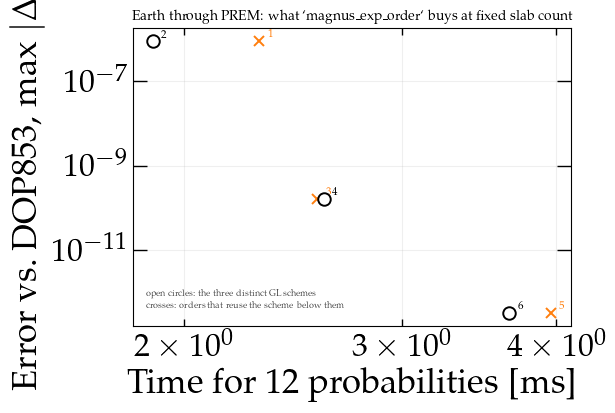

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for order, t, err in rows_ord:
    marker = 'o' if order in (2, 4, 6) else 'x'
    ax.loglog(1.0e3*t, max(err, 1.0e-16), marker, ms=9 if order in (2, 4, 6) else 7,
              mfc='white' if order in (2, 4, 6) else 'C1',
              color='k' if order in (2, 4, 6) else 'C1', mew=1.4, zorder=4)
    ax.annotate(str(order), xy=(1.0e3*t, max(err, 1.0e-16)), xytext=(6, 3),
                textcoords='offset points', fontsize=8,
                color='k' if order in (2, 4, 6) else 'C1')
ax.set_xlabel('Time for 12 probabilities [ms]')
ax.set_ylabel(r'Error vs.\ DOP853,  max $|\Delta P|$')
ax.set_title(r'Earth through PREM: what `magnus_exp_order` buys at fixed slab count',
             fontsize=10)
ax.grid(True, which='both', alpha=0.2)
ax.text(0.03, 0.06, 'open circles: the three distinct GL schemes\n'
        'crosses: orders that reuse the scheme below them',
        transform=ax.transAxes, fontsize=6.6, color='0.3', linespacing=1.5)
fig.tight_layout(pad=1.2)
fig.savefig('../fig/expansion_order.pdf', bbox_inches='tight')

### A case where the order buys nothing at all

`average=True` on a smooth, position-dependent profile takes the **adiabatic** route: it
decoheres in the matter eigenbasis at production, transports along the levels of the
instantaneous Hamiltonian, and reads out in vacuum. It never propagates -- and therefore never
evaluates a Magnus expansion. The order is accepted, and ignored.

This is worth measuring rather than reasoning about, because "accepted and ignored" is
indistinguishable from "accepted and used but unimportant" until you look.

In [9]:
TABLE_ORD = '../docs/dev/adversarial_batteries/bs05_agsop.dat'
_rows = []
with open(TABLE_ORD) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 12:
            try:
                _rows.append([float(x) for x in f])
            except ValueError:
                continue
_solar = np.array(_rows)
_mean_nucleon = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
_ne = _solar[:, 3]*gd.UNIT_G_PER_CM3/_mean_nucleon*(0.5*(1.0 + _solar[:, 6]))
_x = _solar[:, 1]*gd.SUN_RADIUS*gd.UNIT_KM
_logne = np.log(_ne)
R_SUN_ORD = float(_x[-1])


def ne_sun_ord(l):
    xs = np.clip(np.asarray(l, dtype=float), _x[0], _x[-1])
    out = np.exp(np.interp(xs, _x, _logne))
    return out[()] if np.ndim(out) == 0 else out


E_SUN_ORD = np.logspace(np.log10(0.1), np.log10(20.0), 40)*gd.UNIT_MEV
print('THE SUN, average=True (the adiabatic route)')
print('%8s %12s %26s' % ('order', 'seconds', 'max |P - P(order 2)|'))
print('-'*50)
P_ord2 = None
for order in (2, 4, 6):
    t0 = time.perf_counter()
    P = np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_sun_ord, E_SUN_ORD, R_SUN_ORD, OSC, L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE,
        density_is_of_number_of_electrons=True, average=True,
        magnus_exp_order=order))
    dt = time.perf_counter() - t0
    if P_ord2 is None:
        P_ord2 = P
    print('%8d %12.3f %26.3e' % (order, dt, float(np.max(np.abs(P - P_ord2)))))

THE SUN, average=True (the adiabatic route)
   order      seconds       max |P - P(order 2)|
--------------------------------------------------


       2        0.657                  0.000e+00


       4        0.684                  0.000e+00


       6        0.660                  0.000e+00


**Bit-identical, and the same cost.** Not "small", not "below tolerance" -- exactly
zero, because the expansion is never reached. If you are averaging over a smooth profile,
`magnus_exp_order` is not a dial you have.

The opposite extreme is a profile with a genuine discontinuity, where the order matters but the
*slabs* matter more: no order resolves a front that a slab edge straddles, which is what
`t_breakpoints` is for. Measured on notebook 14's supernova shock with the front declared and
the slab count fixed at 8000, order 2 gives $9.5\times10^{-5}$, order 4 gives
$2.5\times10^{-7}$ and order 6 gives $1.1\times10^{-8}$ -- so the order still pays there, about
**385x** for the first step and **22x** for the second, at 1.4x and 1.8x the cost. Notebook 25
runs that case against other codes in full.

### The recommendation

**Leave it at 4.** That is the default, and it is the right one: it is the first scheme that is
genuinely fourth order, it costs under twice what order 2 costs, and on every profile measured
here it buys between two and five orders of magnitude over order 2.

Raise it to **6** when the profile is **smooth** and the target accuracy is tight. What that
extra node buys depends strongly on the profile: about **22x** on the resolved shock front
below, for roughly 1.8x the time. The PREM chord in section 4 cannot price that step -- order 6
lands below what its referee resolves -- though it does price the one below it, at about 5600x
for order 2 to 4. Smoother profiles pay better, which is the same ordering the slab-refinement
rate follows.

Do **not** raise it when a `MagnusConvergenceWarning` appears. That warning means a slab is too
wide for the series to converge on, and a higher-order truncation of a series that is not
converging is not a better answer -- add slabs, or declare the structure with `t_breakpoints`.

Order **1 or 2** is right only when the Hamiltonian is genuinely constant, where every term past
$\Omega_1$ vanishes identically; `osc_prob` already forces order 1 in that case, so this is a
setting you do not need to reach for.

## 5. Unitarity does not depend on the truncation

Section 4 measured what the order buys in *accuracy*. This measures what it costs in
*correctness*, and the answer is nothing: **every truncation of the Magnus series lives in the
Lie algebra**, so the operator it exponentiates is unitary exactly, not to the accuracy of the
truncation.

The sweep raises the order from 1 to 10 on a smooth exponential profile at a deliberately
coarse four slabs, so the order is the only thing moving. `integration_method='simpson'` is
used rather than the default `gl`, because Gauss--Legendre nodes coincide in pairs and `gl`
offers only three distinct schemes wearing six names --- the answer would freeze every second
point.

The left panel is the answer converging. The right panel is the point.

Worst departure from unitarity over all 10 orders: 3.22e-15


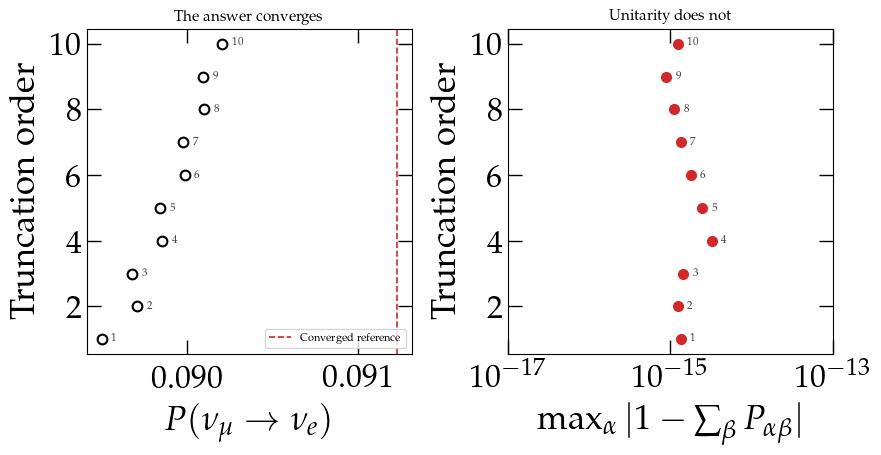

In [10]:
PER_NE_ORD = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)
L_ORD = 4000.0*gd.CONV_KM_TO_INV_EV


def ne_expo_ord(l):
    return (1.0e-13*np.exp(-2.5*np.asarray(l, dtype=float)/L_ORD))/PER_NE_ORD


def truncated(order, n_slabs=4):
    """The full 3x3 probability matrix at one truncation order."""
    return np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_expo_ord, 1.0*gd.UNIT_GEV, L_ORD, OSC, L0=0.0,
        density_is_of_number_of_electrons=True, strategy='magnus',
        magnus_exp_order=order, integration_method='simpson',
        n_slabs=n_slabs, min_n_slabs=n_slabs, max_n_slabs=max(n_slabs, 2),
        rtol=1.0e-13, atol=1.0e-15)).reshape(3, 3)


ORDERS = list(range(1, gd.MAGNUS_EXP_ORDER_MAX + 1))
series = [truncated(k) for k in ORDERS]
p_series = [m[gd.NUMU, gd.NUE] for m in series]
unitarity = [float(np.max(np.abs(m.sum(axis=1) - 1.0))) for m in series]
# The converged value, at the DEFAULT order: at 600 slabs the answer no longer
# depends on the order, which is what lets it referee the sweep.  Asking for the
# top order at that slab count is what killed this cell the first time --
# `magnus._validate` warns order 10 costs about 17x order 6.
p_ref_ord = float(truncated(4, n_slabs=600)[gd.NUMU, gd.NUE])

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.5))
ax = axes[0]
ax.plot(p_series, ORDERS, 'o', ms=7, color='k', mfc='white', mew=1.5)
for k, p in zip(ORDERS, p_series):
    ax.annotate(str(k), xy=(p, k), xytext=(7, 0), textcoords='offset points',
                fontsize=8, va='center', color='0.25')
ax.axvline(p_ref_ord, color='C3', ls='--', lw=1.2, label='Converged reference')
ax.set_xlabel(r'$P(\nu_\mu \to \nu_e)$')
ax.set_ylabel('Truncation order')
ax.set_title('The answer converges', fontsize=11)
ax.set_aspect(1.0/ax.get_data_ratio())               # 1:1 panel
ax.legend(fontsize=8, loc='lower right')

ax = axes[1]
ax.semilogx(np.maximum(unitarity, 1.0e-18), ORDERS, 'o', ms=7, color='C3')
for k, u in zip(ORDERS, unitarity):
    ax.annotate(str(k), xy=(max(u, 1.0e-18), k), xytext=(7, 0),
                textcoords='offset points', fontsize=8, va='center', color='0.25')
ax.set_xlim(1.0e-17, 1.0e-13)
ax.set_xlabel(r'$\max_\alpha |1 - \sum_\beta P_{\alpha\beta}|$')
ax.set_ylabel('Truncation order')
ax.set_title('Unitarity does not', fontsize=11)
ax.set_aspect(1.0/ax.get_data_ratio())
fig.tight_layout(pad=1.0)
fig.savefig('../fig/expansion_unitarity.pdf', bbox_inches='tight')

print('Worst departure from unitarity over all %d orders: %.2e' % (len(ORDERS),
                                                                  max(unitarity)))

**A truncated series that is still exactly unitary** is the property the whole method
rests on: probabilities are non-negative and sum to one at machine precision at *any* accuracy
setting, so an under-resolved answer is a wrong probability rather than not a probability at
all. An adaptive Runge--Kutta integrator drifts off the unitary manifold instead, by around
$10^{-6}$ at typical tolerances and worse with baseline.

## 6. Which engine answers, and what makes it change

`strategy='auto'` is not one method. It tries an adiabatic-plus-patch propagator first and
falls back to the slab ladder wherever that declines --- and **which one answers depends on
what you asked for**, not only on the physics.

The setting below is fixed and deliberately hard: a **15 MeV** electron neutrino crossing a
**supernova shock front**, along a ray from $10^4$ to $8\times10^4$ km, with the front at
$3\times10^4$ km and a width of a thousandth of the ray. Only the requested tolerance changes.

Sweeping a *physical* parameter does not show this. Measured across four decades of baseline
and three of energy on smooth exponential profiles, the answer is `hybrid`/`adiabatic` every
time with nothing declined. The tolerance is the axis that moves it.

     rtol  engine   family         declined, and why
    1e-02  hybrid   adiabatic      --
    1e-03  hybrid   adiabatic      --
    1e-04  magnus   magnus-ladder  did not self-certify at the requested tolerance
    1e-05  magnus   magnus-ladder  did not self-certify at the requested tolerance
    1e-06  magnus   magnus-ladder  did not self-certify at the requested tolerance
    1e-07  magnus   magnus-ladder  did not self-certify at the requested tolerance
    1e-08  magnus   magnus-ladder  did not self-certify at the requested tolerance
    1e-09  magnus   magnus-ladder  did not self-certify at the requested tolerance
    1e-10  magnus   magnus-ladder  did not self-certify at the requested tolerance


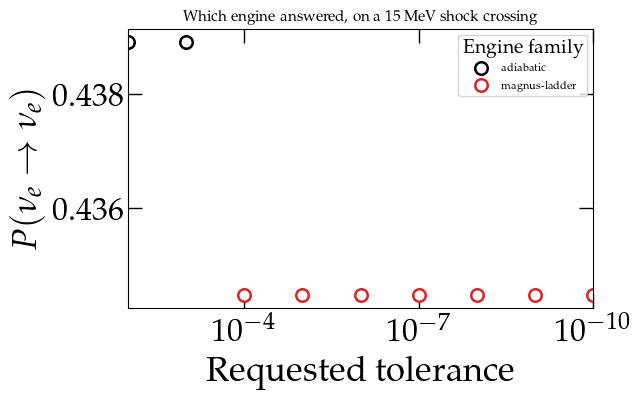

In [11]:
MEAN_NUCLEON_D = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
R0_D, R1_D, W_D, RF_D = 1.0e4, 8.0e4, 1.0e-3, 3.0e4
KM_D = gd.CONV_KM_TO_INV_EV


def ne_shock_d(l):
    w_km = W_D*(R1_D - R0_D)
    r = np.asarray(l, dtype=float)/KM_D
    u = np.clip((RF_D + 0.5*w_km - r)/w_km, 0.0, 1.0)
    out = (1.0e14*r**(-2.4)*(1.0 + (u*u*(3.0 - 2.0*u))*9.0)
           * gd.UNIT_G_PER_CM3/MEAN_NUCLEON_D*0.5)
    return out[()] if np.ndim(out) == 0 else out


def who_answered(rtol):
    info = {}
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p = float(np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne_shock_d, 15.0*gd.UNIT_MEV, R1_D*KM_D, OSC, L0=R0_D*KM_D,
            density_is_of_number_of_electrons=True, nu_i=gd.NUE, nu_f=gd.NUE,
            rtol=rtol, atol=rtol*1.0e-2, strategy_info=info)))
    return p, info.get('engine', '?'), info.get('family', '?'), \
        info.get('declined') or []


TOL_D = np.logspace(-2, -10, 9)
dispatch = [who_answered(t) for t in TOL_D]
fams_d = sorted({d[2] for d in dispatch})
palette_d = {f: c for f, c in zip(fams_d, ['k', 'C3', 'C0'])}

fig, ax = plt.subplots(figsize=(6.6, 4.2))
for fam in fams_d:
    sel = [i for i, d in enumerate(dispatch) if d[2] == fam]
    ax.semilogx(TOL_D[sel], [dispatch[i][0] for i in sel], 'o', ms=9,
                color=palette_d[fam], mfc='white', mew=1.8, label=fam)
ax.set_xlabel('Requested tolerance')
ax.set_ylabel(r'$P(\nu_e \to \nu_e)$')
ax.set_title('Which engine answered, on a 15 MeV shock crossing', fontsize=11)
ax.set_xlim(TOL_D[0], TOL_D[-1])
ax.legend(fontsize=8, title='Engine family')
fig.tight_layout(pad=1.0)
fig.savefig('../fig/dispatch_vs_tolerance.pdf', bbox_inches='tight')

print('%9s  %-8s %-14s %s' % ('rtol', 'engine', 'family', 'declined, and why'))
for t, d in zip(TOL_D, dispatch):
    print('%9.0e  %-8s %-14s %s' % (t, d[1], d[2], d[3][0][1] if d[3] else '--'))

**The reason travels with the decision**, which is the part worth having: the request
did not silently change engine, it changed engine *because* the adiabatic route could not
self-certify at the tolerance asked for, and `strategy_info['declined']` says exactly that. An
answer that arrives with a stated reason for the route taken is a very different object from
one that does not.

Notebook 22 takes this further --- every engine, what each shares with the others, and how to
ask for one by name.

---

**Previous:** [When averaging rescues you](23_magnus_when_averaging_helps.ipynb)  
**Next:** [Against other codes](25_magnus_against_other_codes.ipynb) --- where a closed form wins, and a conventions trap that looks like accuracy  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Documentation](https://mbustama.github.io/Magnus/) &middot; [All notebooks](.)